# Edge Layer — Anomaly Detection Model Training
## Fog and Edge Computing for Renewable Energy-Based Carbon Credit Generation in Smart Cities

**Purpose:** Train an Isolation Forest model on real sensor data to detect anomalous readings at the edge node before data reaches the fog layer and blockchain.

**Approach:**
- Train on first 70% of dataset (normal operating history)
- No fake anomaly injection — model learns real normal patterns
- Save model for deployment in `edge_node.py` during MQTT simulation

**Architecture position:**
```
MQTT Sensor Stream
       ↓
EDGE NODE ← edge_anomaly_model.pkl deployed here
  Normal  → forward to fog
  Anomaly → log and discard
       ↓
FOG NODE → carbon credit calculation → blockchain
```

In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
# Cell 2: Load Raw Datasets
solar      = pd.read_csv('solar_power_generation.csv')
wind       = pd.read_csv('wind_turbine_data.csv')
demand_raw = pd.read_excel('open_power_system_data.xlsx', header=None)

print('Solar  shape:', solar.shape)
print('Wind   shape:', wind.shape)
print('Demand shape:', demand_raw.shape)

Solar  shape: (68778, 7)
Wind   shape: (50530, 5)
Demand shape: (201611, 61)


In [3]:
# Cell 3: Preprocess Solar Dataset
solar['DATE_TIME'] = pd.to_datetime(solar['DATE_TIME'], dayfirst=True)
solar = solar.groupby('DATE_TIME')['AC_POWER'].sum().reset_index()
solar = solar.rename(columns={'DATE_TIME': 'timestamp', 'AC_POWER': 'solar_power'})
solar = solar.resample('h', on='timestamp').mean().reset_index()
solar = solar.dropna()
print('Solar shape:', solar.shape)
print(solar.head(3))

Solar shape: (796, 2)
            timestamp  solar_power
0 2020-05-15 00:00:00          0.0
1 2020-05-15 01:00:00          0.0
2 2020-05-15 02:00:00          0.0


In [4]:
# Cell 4: Preprocess Wind Dataset
wind['Date/Time'] = pd.to_datetime(wind['Date/Time'], dayfirst=True)
wind = wind.rename(columns={
    'Date/Time'           : 'timestamp',
    'LV ActivePower (kW)' : 'wind_power',
    'Wind Speed (m/s)'    : 'wind_speed'
})
wind = wind.resample('h', on='timestamp').agg({
    'wind_power': 'mean',
    'wind_speed': 'mean'
}).reset_index()
wind = wind.dropna()
print('Wind shape:', wind.shape)
print(wind.head(3))

Wind shape: (8439, 3)
            timestamp  wind_power  wind_speed
0 2018-01-01 00:00:00  390.480362    5.506868
1 2018-01-01 01:00:00  460.537125    5.644205
2 2018-01-01 02:00:00  733.655375    6.452037


In [5]:
# Cell 5: Preprocess Demand Dataset
de_col = None
for col in demand_raw.columns:
    if (str(demand_raw.iloc[0, col]) == 'DE' and
        str(demand_raw.iloc[1, col]) == 'load' and
        'actual' in str(demand_raw.iloc[2, col]).lower()):
        de_col = col
        print(f'Found DE actual load at column {de_col}')
        break

timestamps = demand_raw.iloc[7:, 0].tolist()
values     = demand_raw.iloc[7:, de_col].tolist()

demand = pd.DataFrame({'timestamp': timestamps, 'demand': values})
demand['timestamp'] = pd.to_datetime(demand['timestamp'], errors='coerce')
demand['demand']    = pd.to_numeric(demand['demand'], errors='coerce')
demand = demand.dropna()
demand = demand.resample('h', on='timestamp').mean().reset_index()
demand = demand.dropna()
print('Demand shape:', demand.shape)
print(demand.head(3))

Found DE actual load at column 9
Demand shape: (50400, 2)
            timestamp        demand
0 2015-01-01 00:00:00  41151.096667
1 2015-01-01 01:00:00  40135.142500
2 2015-01-01 02:00:00  39106.015000


In [6]:
# Cell 6: Combine by Row Alignment + Feature Engineering
solar_vals  = solar[['solar_power']].reset_index(drop=True)
wind_vals   = wind[['wind_power', 'wind_speed']].reset_index(drop=True)
demand_vals = demand[['demand']].reset_index(drop=True)

min_len = min(len(solar_vals), len(wind_vals), len(demand_vals))
print(f'Aligning to {min_len} rows')

df = pd.concat([
    solar_vals.iloc[:min_len],
    wind_vals.iloc[:min_len],
    demand_vals.iloc[:min_len]
], axis=1).reset_index(drop=True)

df = df.dropna()
print('Combined shape:', df.shape)
print(df.head(3))

Aligning to 796 rows
Combined shape: (796, 4)
   solar_power  wind_power  wind_speed        demand
0          0.0  390.480362    5.506868  41151.096667
1          0.0  460.537125    5.644205  40135.142500
2          0.0  733.655375    6.452037  39106.015000


In [7]:
# Cell 7: Split — first 70% for training, last 30% reserved for MQTT simulation
features = ['solar_power', 'wind_power', 'wind_speed', 'demand']
X = df[features]

split_idx = int(len(X) * 0.70)
X_train = X.iloc[:split_idx].reset_index(drop=True)
X_sim   = X.iloc[split_idx:].reset_index(drop=True)   # used later by sensor_simulator.py

print(f'Training rows  : {len(X_train)}  (first 70% — normal operating history)')
print(f'Simulation rows: {len(X_sim)}   (last 30%  — replayed during MQTT simulation)')
print()
print('Training data stats:')
print(X_train.describe().round(2))

Training rows  : 557  (first 70% — normal operating history)
Simulation rows: 239   (last 30%  — replayed during MQTT simulation)

Training data stats:
       solar_power  wind_power  wind_speed    demand
count       557.00      557.00      557.00    557.00
mean       6861.71     1491.61        8.64  56212.87
std        8596.73     1404.92        4.45  10004.45
min           0.00       -0.07        0.69  35591.60
25%           0.00       63.87        5.31  48011.28
50%        1187.90      967.05        8.18  55753.26
75%       14119.45     3187.11       12.18  66543.11
max       27325.90     3604.41       20.77  72114.78


In [8]:
# Cell 8: Scale Features
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)

print('Scaler fitted on training data')
print('Mean :', scaler.mean_.round(2))
print('Std  :', scaler.scale_.round(2))

Scaler fitted on training data
Mean : [6.861710e+03 1.491610e+03 8.640000e+00 5.621287e+04]
Std  : [8.58901e+03 1.40366e+03 4.45000e+00 9.99547e+03]


Isolation Forest trained successfully
Readings flagged as anomalous in training data: 28 / 557 (5.0%)
Expected ~5% based on contamination parameter


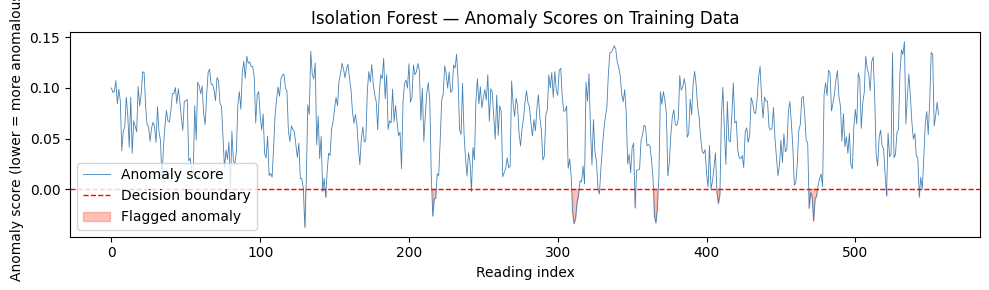

Saved: training_anomaly_scores.png


In [9]:
# Cell 9: Train Isolation Forest
# contamination=0.05 means we expect ~5% of live readings to be anomalous
# n_estimators=50 keeps model small for edge deployment

# Cell 9: Change this line
iso_forest = IsolationForest(
    n_estimators=20,        # reduced from 50 → smaller model
    contamination=0.05,
    random_state=42
)
iso_forest.fit(X_train_sc)

# Quick sanity check on training data itself
train_preds = iso_forest.predict(X_train_sc)
flagged     = (train_preds == -1).sum()
print(f'Isolation Forest trained successfully')
print(f'Readings flagged as anomalous in training data: {flagged} / {len(X_train)} ({flagged/len(X_train)*100:.1f}%)')
print(f'Expected ~5% based on contamination parameter')

# Plot anomaly scores on training data
scores = iso_forest.decision_function(X_train_sc)
plt.figure(figsize=(10, 3))
plt.plot(scores, color='steelblue', linewidth=0.6, label='Anomaly score')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Decision boundary')
plt.fill_between(range(len(scores)), scores, 0,
                where=(scores < 0), color='tomato', alpha=0.4, label='Flagged anomaly')
plt.title('Isolation Forest — Anomaly Scores on Training Data')
plt.xlabel('Reading index')
plt.ylabel('Anomaly score (lower = more anomalous)')
plt.legend()
plt.tight_layout()
plt.savefig('training_anomaly_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_anomaly_scores.png')

In [10]:
# Cell 10: Save Model and Simulation Data
with open('edge_anomaly_model.pkl', 'wb') as f:
    pickle.dump(iso_forest, f)

with open('edge_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save simulation data so sensor_simulator.py can replay it
X_sim.to_csv('simulation_data.csv', index=False)

model_size  = os.path.getsize('edge_anomaly_model.pkl') / 1024
scaler_size = os.path.getsize('edge_scaler.pkl')        / 1024
sim_size    = os.path.getsize('simulation_data.csv')    / 1024

print('=== Files Saved ===')
print(f'edge_anomaly_model.pkl : {model_size:.1f} KB  → deploy on edge node')
print(f'edge_scaler.pkl        : {scaler_size:.2f} KB  → deploy on edge node')
print(f'simulation_data.csv    : {sim_size:.1f} KB  → used by sensor_simulator.py')
print()
print(f'Total edge deployment size: {model_size + scaler_size:.1f} KB')
print(f'TinyML suitable (< 500 KB): {(model_size + scaler_size) < 500}')
print()
print('Next step: MQTT simulation pipeline')
print('  sensor_simulator.py → reads simulation_data.csv, publishes to MQTT')
print('  edge_node.py        → loads edge_anomaly_model.pkl, filters anomalies')
print('  fog_node.py         → calculates credits, mints on blockchain')

=== Files Saved ===
edge_anomaly_model.pkl : 349.8 KB  → deploy on edge node
edge_scaler.pkl        : 0.63 KB  → deploy on edge node
simulation_data.csv    : 13.0 KB  → used by sensor_simulator.py

Total edge deployment size: 350.5 KB
TinyML suitable (< 500 KB): True

Next step: MQTT simulation pipeline
  sensor_simulator.py → reads simulation_data.csv, publishes to MQTT
  edge_node.py        → loads edge_anomaly_model.pkl, filters anomalies
  fog_node.py         → calculates credits, mints on blockchain


=== Performance on Simulation Data (last 30%) ===
Total readings  : 239
Normal          : 182  (76.2%)
Anomalies flagged: 57 (23.8%)

=== Anomaly Score Statistics ===
Mean score  : 0.0444
Min score   : -0.0745  (most anomalous)
Max score   : 0.1370  (most normal)
Std dev     : 0.0545



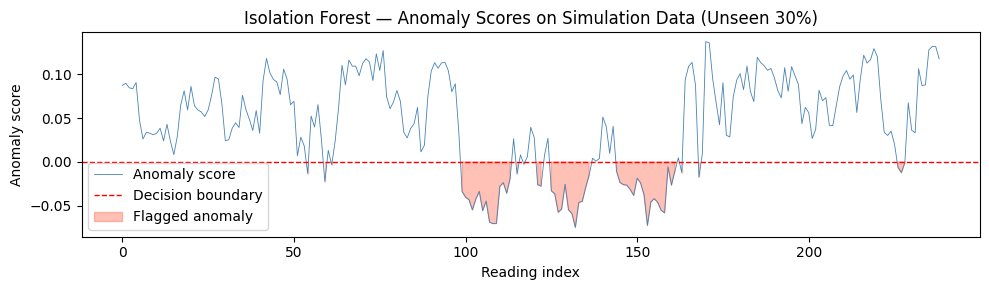

Saved: simulation_anomaly_scores.png


In [11]:
# Cell 11: Evaluate on simulation data (last 30%)

features = ['solar_power', 'wind_power', 'wind_speed', 'demand']
X_sim_sc = scaler.transform(X_sim[features])

# Get predictions on simulation data
sim_preds  = iso_forest.predict(X_sim_sc)
sim_scores = iso_forest.decision_function(X_sim_sc)

normal_count  = (sim_preds ==  1).sum()
anomaly_count = (sim_preds == -1).sum()
total         = len(sim_preds)

print('=== Performance on Simulation Data (last 30%) ===')
print(f'Total readings  : {total}')
print(f'Normal          : {normal_count}  ({normal_count/total*100:.1f}%)')
print(f'Anomalies flagged: {anomaly_count} ({anomaly_count/total*100:.1f}%)')
print()

# Score distribution stats
print('=== Anomaly Score Statistics ===')
print(f'Mean score  : {sim_scores.mean():.4f}')
print(f'Min score   : {sim_scores.min():.4f}  (most anomalous)')
print(f'Max score   : {sim_scores.max():.4f}  (most normal)')
print(f'Std dev     : {sim_scores.std():.4f}')
print()

# Plot score distribution on simulation data
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
plt.plot(sim_scores, color='steelblue', linewidth=0.6, label='Anomaly score')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Decision boundary')
plt.fill_between(range(len(sim_scores)), sim_scores, 0,
                where=(sim_scores < 0), color='tomato', alpha=0.4, label='Flagged anomaly')
plt.title('Isolation Forest — Anomaly Scores on Simulation Data (Unseen 30%)')
plt.xlabel('Reading index')
plt.ylabel('Anomaly score')
plt.legend()
plt.tight_layout()
plt.savefig('simulation_anomaly_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: simulation_anomaly_scores.png')

In [12]:
# Performance Metrics Cell — Rule-based ground truth comparison
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Create rule-based ground truth labels for simulation data
# A reading is "truly anomalous" if it violates physical sensor constraints
def rule_based_label(row):
    if row['solar_power'] < 0:                    return 1  # impossible
    if row['wind_power'] < 0:                     return 1  # impossible  
    if row['wind_speed'] < 0 or row['wind_speed'] > 50:  return 1  # impossible
    if row['demand'] <= 0:                        return 1  # impossible
    if row['solar_power'] > 5000:                 return 1  # exceeds plant capacity
    if row['wind_power'] > 3000:                  return 1  # exceeds turbine capacity
    # Wind speed vs power inconsistency
    if row['wind_speed'] > 20 and row['wind_power'] < 10: return 1  # physically inconsistent
    return 0  # normal

# Apply rule-based labels to simulation data
y_true = X_sim.apply(rule_based_label, axis=1).values

# Get model predictions
X_sim_sc   = scaler.transform(X_sim[features])
sim_preds  = iso_forest.predict(X_sim_sc)
y_pred     = np.where(sim_preds == -1, 1, 0)

print('=== Performance Metrics ===')
print(f'Accuracy  : {accuracy_score(y_true,  y_pred):.4f}')
print(f'Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}')
print(f'Recall    : {recall_score(y_true,    y_pred, zero_division=0):.4f}')
print(f'F1 Score  : {f1_score(y_true,        y_pred, zero_division=0):.4f}')
print()
print(f'True anomalies (rule-based) : {y_true.sum()}')
print(f'Flagged by model            : {y_pred.sum()}')
print(f'Correctly flagged           : {((y_true==1) & (y_pred==1)).sum()}')

=== Performance Metrics ===
Accuracy  : 0.6025
Precision : 0.9825
Recall    : 0.3733
F1 Score  : 0.5411

True anomalies (rule-based) : 150
Flagged by model            : 57
Correctly flagged           : 56
